# Bayesian Multinomial Logit with Pyro

In [1]:
import pandas as pd
import numpy as np
import torch
import pyro
import pyro.distributions as dist
import pyro.poutine as poutine
from pyro.infer import MCMC, NUTS
from pyro.infer import SVI, TraceEnum_ELBO
from pyro.infer.autoguide import AutoNormal
from pyro.optim import ClippedAdam
from pyro.ops.indexing import Vindex
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logsumexp, softmax
from scipy.optimize import minimize

# Set seeds for reproducibility
np.random.seed(11)
torch.manual_seed(11)
pyro.set_rng_seed(11)

## Load and explore data

In [2]:
df = pd.read_csv('swissmetro.dat', sep='\t')
print(df.head())
print(df.shape)

# Keep only observations with known age, explicit choices, and non-'other' trip purposes.
# In this file, AGE==6 is the unknown age code and PURPOSE==9 is 'other'.
valid_age = df['AGE'].notna() & (df['AGE'] != 6)
valid_choice = df['CHOICE'] != 0
valid_purpose = df['PURPOSE'] != 9
df = df[valid_age & valid_choice & valid_purpose].copy()

print("Filtered shape:", df.shape)

# -----------------------------
# Train / Test split
# -----------------------------
# IMPORTANT:
# split by individual ID, not by row
# to avoid the same person appearing in both train and test

from sklearn.model_selection import train_test_split


unique_ids = df["ID"].unique()

train_ids, test_ids = train_test_split(
    unique_ids,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_df = df[df["ID"].isin(train_ids)].copy()
test_df = df[df["ID"].isin(test_ids)].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train persons:", train_df["ID"].nunique())
print("Test persons:", test_df["ID"].nunique())


# -----------------------------
# Attribute-level scaling
# -----------------------------
# One scaling rule for all travel time variables
# One scaling rule for all travel cost variables
# Fit on train only, apply to both train and test
# As long as our utility function is like this: U = beta_tt * tt + beta_co * co + ASC

tt_cols = ["TRAIN_TT", "SM_TT", "CAR_TT"]
co_cols = ["TRAIN_CO", "SM_CO", "CAR_CO"]

# calculate train-only scaling factors
tt_train_values = train_df[tt_cols].values.reshape(-1)
co_train_values = train_df[co_cols].values.reshape(-1)

tt_mean = tt_train_values.mean()
tt_std = tt_train_values.std()

co_mean = co_train_values.mean()
co_std = co_train_values.std()

# apply same TT scaling to all TT columns
for col in tt_cols:
    train_df[col + "_SCALED"] = (train_df[col] - tt_mean) / tt_std
    test_df[col + "_SCALED"] = (test_df[col] - tt_mean) / tt_std

# apply same CO scaling to all CO columns
for col in co_cols:
    train_df[col + "_SCALED"] = (train_df[col] - co_mean) / co_std
    test_df[col + "_SCALED"] = (test_df[col] - co_mean) / co_std

print("TT scaling factor:")
print(f"mean = {tt_mean:.3f}, std = {tt_std:.3f}")

print("\nCO scaling factor:")
print(f"mean = {co_mean:.3f}, std = {co_std:.3f}")

print("\nTrain preview:")
print(train_df[[
    "TRAIN_TT_SCALED", "SM_TT_SCALED", "CAR_TT_SCALED",
    "TRAIN_CO_SCALED", "SM_CO_SCALED", "CAR_CO_SCALED",
    "CHOICE"
]].head())


# -----------------------------
# Quick check
# -----------------------------
print("\nTraining scaled preview:")
print(
    train_df[
        [
            "TRAIN_TT_SCALED",
            "TRAIN_CO_SCALED",
            "SM_TT_SCALED",
            "SM_CO_SCALED",
            "CHOICE"
        ]
    ].head()
)




   GROUP  SURVEY  SP  ID  PURPOSE  FIRST  TICKET  WHO  LUGGAGE  AGE  ...  \
0      2       0   1   1        1      0       1    1        0    3  ...   
1      2       0   1   1        1      0       1    1        0    3  ...   
2      2       0   1   1        1      0       1    1        0    3  ...   
3      2       0   1   1        1      0       1    1        0    3  ...   
4      2       0   1   1        1      0       1    1        0    3  ...   

   TRAIN_TT  TRAIN_CO  TRAIN_HE  SM_TT  SM_CO  SM_HE  SM_SEATS  CAR_TT  \
0       112        48       120     63     52     20         0     117   
1       103        48        30     60     49     10         0     117   
2       130        48        60     67     58     30         0     117   
3       103        40        30     63     52     20         0      72   
4       130        36        60     63     42     20         0      90   

   CAR_CO  CHOICE  
0      65       2  
1      84       2  
2      52       2  
3      52       2 

## Create long-format data for MNL estimation

In [3]:
# Create long-format data for MNL estimation
# Each row observation becomes 3 rows (one per alternative that is available)
def create_long_format(df):
    long_data = []

    # Create a mapping from original indices to sequential obs_id (0, 1, 2, ...)
    obs_id_map = {orig_idx: new_idx for new_idx, orig_idx in enumerate(df.index.unique())}

    for idx, row in df.iterrows():
        obs_id_sequential = obs_id_map[idx]  # Map to sequential ID
        original_id = row['ID']  # Keep track of the individual ID
        
        # Train (alt_id 0)
        if row['TRAIN_AV'] == 1:
            long_data.append({
                'obs_id': obs_id_sequential,
                'ID': original_id,
                'alt_id': 0,
                'tt': row['TRAIN_TT_SCALED'],
                'co': row['TRAIN_CO_SCALED'],
                'choice': 1 if row['CHOICE'] == 1 else 0
            })
        
        # SwissMetro (alt_id 1)
        if row['SM_AV'] == 1:
            long_data.append({
                'obs_id': obs_id_sequential,
                'ID': original_id,
                'alt_id': 1,
                'tt': row['SM_TT_SCALED'],
                'co': row['SM_CO_SCALED'],
                'choice': 1 if row['CHOICE'] == 2 else 0
            })
        
        # Car (alt_id 2)
        if row['CAR_AV'] == 1:
            long_data.append({
                'obs_id': obs_id_sequential,
                'ID': original_id,
                'alt_id': 2,
                'tt': row['CAR_TT_SCALED'],
                'co': row['CAR_CO_SCALED'],
                'choice': 1 if row['CHOICE'] == 3 else 0
            })

    long_df = pd.DataFrame(long_data)

    # Validate: exactly one choice per obs_id
    choices_per_obs = long_df.groupby('obs_id')['choice'].sum()
    assert (choices_per_obs == 1).all(), "Error: some observations have != 1 choice"
    print("✓ Validation passed: exactly one choice per observation")

    print(f"\nLong format shape: {long_df.shape}")
    print(f"Number of unique observations: {long_df['obs_id'].nunique()}")
    print(f"Number of unique individuals: {long_df['ID'].nunique()}")
    print(f"Obs_id range: [{long_df['obs_id'].min()}, {long_df['obs_id'].max()}]")
    print(f"\nSample (first 9 rows = 3 obs):")
    long_df.head(9)
    return long_df

In [5]:
long_df_train = create_long_format(train_df)
long_df_test = create_long_format(test_df)

print("\nTrain dataset long format preview:")
print(f"\nLong format shape: {long_df_train.shape}")
print(f"Number of unique observations: {long_df_train['obs_id'].nunique()}")
print(f"Number of unique individuals: {long_df_train['ID'].nunique()}")
print(f"Obs_id range: [{long_df_train['obs_id'].min()}, {long_df_train['obs_id'].max()}]")
print(f"\nSample (first 9 rows = 3 obs):", long_df_train.head(9))


print("\nTest dataset long format preview:")
print(f"\nLong format shape: {long_df_test.shape}")
print(f"Number of unique observations: {long_df_test['obs_id'].nunique()}")
print(f"Number of unique individuals: {long_df_test['ID'].nunique()}")
print(f"Obs_id range: [{long_df_test['obs_id'].min()}, {long_df_test['obs_id'].max()}]")
print(f"\nSample (first 9 rows = 3 obs):")

assert (long_df_test.groupby("obs_id")["choice"].sum() == 1).all()
assert (long_df_train.groupby("obs_id")["choice"].sum() == 1).all()

long_df_test.head(9)


✓ Validation passed: exactly one choice per observation

Long format shape: (24426, 6)
Number of unique observations: 8550
Number of unique individuals: 950
Obs_id range: [0, 8549]

Sample (first 9 rows = 3 obs):
✓ Validation passed: exactly one choice per observation

Long format shape: (5985, 6)
Number of unique observations: 2142
Number of unique individuals: 238
Obs_id range: [0, 2141]

Sample (first 9 rows = 3 obs):

Train dataset long format preview:

Long format shape: (24426, 6)
Number of unique observations: 8550
Number of unique individuals: 950
Obs_id range: [0, 8549]

Sample (first 9 rows = 3 obs):    obs_id   ID  alt_id        tt        co  choice
0       0  1.0       0 -0.183973 -0.339752       0
1       0  1.0       1 -0.771832 -0.335906       1
2       0  1.0       2 -0.123988 -0.323408       0
3       1  1.0       0 -0.291947 -0.339752       0
4       1  1.0       1 -0.807824 -0.338791       1
5       1  1.0       2 -0.123988 -0.305141       0
6       2  1.0       0  0

,obs_id,ID,alt_id,tt,co,choice
0,0,11.0,0,-0.135985,-0.355135,0
1,0,11.0,1,-0.903801,-0.349366,1
2,1,11.0,0,-0.135985,-0.355135,0
3,1,11.0,1,-0.951789,-0.344559,1
4,2,11.0,0,-0.135985,-0.358019,0
5,2,11.0,1,-0.987781,-0.347444,1
6,3,11.0,0,-0.411919,-0.358019,0
7,3,11.0,1,-0.987781,-0.347444,1
8,4,11.0,0,-0.315942,-0.355135,0


## LCCM (add latent class)

In [7]:
# -----------------------------
# 1. Recoding functions
# -----------------------------
def recode_membership_variables(person_df):
    person_df = person_df.copy()

    # Paper-style income recoding:
    # 0 or 1: under 50
    # 2: 50-100
    # 3: over 100
    # 4: unknown
    income_map = {
        0: 1,
        1: 1,
        2: 2,
        3: 3,
        4: 4,
    }
    person_df["INCOME_REC"] = person_df["INCOME"].map(income_map)

    # Paper-style luggage recoding:
    # 0: none
    # 1: one piece
    # 3: several pieces -> 2: more than one piece
    luggage_map = {
        0: 0,
        1: 1,
        3: 2,
    }
    person_df["LUGGAGE_REC"] = person_df["LUGGAGE"].map(luggage_map)

    # Paper-style purpose recoding:
    # 1/5: commuter
    # 2/6: shopping
    # 3/7: business
    # 4/8: leisure
    purpose_map = {
        1: 1, 5: 1,
        2: 2, 6: 2,
        3: 3, 7: 3,
        4: 4, 8: 4,
    }
    person_df["PURPOSE_REC"] = person_df["PURPOSE"].map(purpose_map)

    return person_df


def build_membership_matrix(person_df, include_GA=False, reference_cols=None):
    person_df = recode_membership_variables(person_df)

    binary_vars = ["MALE", "FIRST"]
    if include_GA:
        binary_vars.append("GA")

    Z = person_df[binary_vars].astype(float).copy()

    cat_vars = ["AGE", "INCOME_REC", "LUGGAGE_REC", "PURPOSE_REC"]

    for var in cat_vars:
        dummies = pd.get_dummies(person_df[var], prefix=var, dtype=float)

        # drop first category as base
        dummies = dummies.iloc[:, 1:]

        Z = pd.concat([Z, dummies], axis=1)

    if reference_cols is not None:
        Z = Z.reindex(columns=reference_cols, fill_value=0.0)

    return Z


# -----------------------------
# 2. Prepare LCCM data
# -----------------------------
def prepare_lccm_data(long_df, id_col="ID", include_GA=False, reference_Z_cols=None):
    df = long_df.copy()

    df["obs_id"] = pd.factorize(df["obs_id"])[0]
    df["alt_id"] = df["alt_id"].astype(int)

    assert (df.groupby("obs_id")["choice"].sum() == 1).all()

    obs_person = (
        df.groupby("obs_id")[id_col]
        .first()
        .reset_index()
        .sort_values("obs_id")
    )

    obs_person["person_idx"] = pd.factorize(obs_person[id_col])[0]

    person_obs_id = obs_person["person_idx"].values
    n_persons = obs_person["person_idx"].nunique()

    demo_cols = [id_col, "AGE", "MALE", "INCOME", "FIRST", "LUGGAGE", "PURPOSE"]
    if include_GA:
        demo_cols.append("GA")

    person_df = (
        df.groupby(id_col, as_index=False)
        .first()[demo_cols]
        .copy()
    )

    person_df["person_idx"] = person_df[id_col].map(
        dict(zip(obs_person[id_col], obs_person["person_idx"]))
    )

    person_df = person_df.sort_values("person_idx").reset_index(drop=True)

    Z_df = build_membership_matrix(
        person_df,
        include_GA=include_GA,
        reference_cols=reference_Z_cols
    )

    return {
        "df": df,
        "n_obs": df["obs_id"].nunique(),
        "n_alts": df["alt_id"].nunique(),
        "n_persons": n_persons,
        "tt": df["tt"].values,
        "co": df["co"].values,
        "obs_id": df["obs_id"].values,
        "alt_id": df["alt_id"].values,
        "choice": df["choice"].values,
        "person_obs_id": person_obs_id,
        "Z": Z_df.values.astype(float),
        "Z_cols": Z_df.columns.tolist(),
    }


# -----------------------------
# 3. Parameter unpacking
# -----------------------------
def unpack_lccm_params(params, K, n_alts, n_Z):
    idx = 0

    beta_tt = params[idx:idx + K]
    idx += K

    beta_co = params[idx:idx + K]
    idx += K

    asc_raw = params[idx:idx + K * (n_alts - 1)]
    asc_raw = asc_raw.reshape(K, n_alts - 1)
    idx += K * (n_alts - 1)

    gamma_raw = params[idx:]
    gamma = gamma_raw.reshape(K - 1, n_Z + 1)

    return beta_tt, beta_co, asc_raw, gamma


# -----------------------------
# 4. Log-likelihood
# -----------------------------
def log_likelihood_lccm(params, data, K):
    n_obs = data["n_obs"]
    n_alts = data["n_alts"]
    n_persons = data["n_persons"]
    Z = data["Z"]
    n_Z = Z.shape[1]

    beta_tt, beta_co, asc_raw, gamma = unpack_lccm_params(
        params, K, n_alts, n_Z
    )

    # Membership model
    Z_aug = np.column_stack([np.ones(n_persons), Z])

    eta_nonbase = Z_aug @ gamma.T
    eta = np.column_stack([eta_nonbase, np.zeros(n_persons)])

    log_class_probs = eta - logsumexp(eta, axis=1, keepdims=True)

    # Class-specific choice model
    scen_ll = np.zeros((n_obs, K))

    for k in range(K):
        asc = np.concatenate([[0.0], asc_raw[k]])

        V_long = (
            beta_tt[k] * data["tt"]
            + beta_co[k] * data["co"]
            + asc[data["alt_id"]]
        )

        V_wide = np.full((n_obs, n_alts), -1e10)
        V_wide[data["obs_id"], data["alt_id"]] = V_long

        log_denom = logsumexp(V_wide, axis=1)
        chosen_V = V_long[data["choice"] == 1]

        scen_ll[:, k] = chosen_V - log_denom

    # Person-level likelihood
    person_ll = np.zeros((n_persons, K))

    for t in range(n_obs):
        p = data["person_obs_id"][t]
        person_ll[p, :] += scen_ll[t, :]

    log_marginal = logsumexp(person_ll + log_class_probs, axis=1)

    return log_marginal.sum()


# -----------------------------
# 5. Main function
# -----------------------------
def run_lccm_model(
    long_df_train,
    long_df_test,
    df_original,
    K=2,
    constrained=False,
    include_GA=False,
    n_trials=5,
    id_col="ID",
    random_seed=42,
    verbose=True
):
    """
    Run frequentist LCCM with optional constraints and optional GA in membership model.

    Parameters
    ----------
    K : int
        Number of latent classes.
    constrained : bool
        If True, impose beta_tt <= 0 and beta_co <= 0 for all classes.
    include_GA : bool
        If True, include GA in the membership model.
    n_trials : int
        Number of random initializations.
    """

    demo_cols = [id_col, "AGE", "MALE", "INCOME", "FIRST", "LUGGAGE", "PURPOSE"]
    if include_GA:
        demo_cols.append("GA")

    person_demo = (
        df_original[demo_cols]
        .drop_duplicates(subset=id_col)
        .copy()
    )

    train_df = long_df_train.merge(person_demo, on=id_col, how="left")
    test_df = long_df_test.merge(person_demo, on=id_col, how="left")

    assert train_df[demo_cols].notna().all().all()
    assert test_df[demo_cols].notna().all().all()

    train_data = prepare_lccm_data(
        train_df,
        id_col=id_col,
        include_GA=include_GA
    )

    test_data = prepare_lccm_data(
        test_df,
        id_col=id_col,
        include_GA=include_GA,
        reference_Z_cols=train_data["Z_cols"]
    )

    assert train_data["n_alts"] == test_data["n_alts"]

    n_alts = train_data["n_alts"]
    n_Z = train_data["Z"].shape[1]

    n_params = (
        K
        + K
        + K * (n_alts - 1)
        + (K - 1) * (n_Z + 1)
    )

    def neg_ll(params):
        return -log_likelihood_lccm(params, train_data, K=K)

    if constrained:
        bounds = (
            [(None, 0)] * K
            + [(None, 0)] * K
            + [(None, None)] * (K * (n_alts - 1))
            + [(None, None)] * ((K - 1) * (n_Z + 1))
        )
    else:
        bounds = [(None, None)] * n_params

    best_result = None
    best_nll = np.inf

    rng_master = np.random.default_rng(random_seed)

    for trial in range(n_trials):
        rng = np.random.default_rng(rng_master.integers(1_000_000))

        init_params = rng.normal(0, 0.1, size=n_params)

        if constrained:
            init_params[:K] = -np.abs(rng.normal(1.0, 0.2, size=K))
            init_params[K:2*K] = -np.abs(rng.normal(0.2, 0.1, size=K))
        else:
            init_params[:K] = rng.normal(-1.0, 0.3, size=K)
            init_params[K:2*K] = rng.normal(0.0, 0.3, size=K)

        result = minimize(
            neg_ll,
            init_params,
            method="L-BFGS-B",
            bounds=bounds
        )

        if verbose:
            print(
                f"Trial {trial + 1}/{n_trials} | "
                f"success={result.success} | "
                f"NLL={result.fun:.3f}"
            )

        if result.fun < best_nll:
            best_nll = result.fun
            best_result = result

    params_hat = best_result.x

    train_ll = log_likelihood_lccm(params_hat, train_data, K=K)
    test_ll = log_likelihood_lccm(params_hat, test_data, K=K)

    beta_tt, beta_co, asc, gamma = unpack_lccm_params(
        params_hat, K, n_alts, n_Z
    )

    # Choice coefficient table
    choice_rows = []

    for k in range(K):
        choice_rows.append({
            "class": k + 1,
            "parameter": "beta_tt",
            "estimate": beta_tt[k]
        })
        choice_rows.append({
            "class": k + 1,
            "parameter": "beta_co",
            "estimate": beta_co[k]
        })

        for j in range(1, n_alts):
            choice_rows.append({
                "class": k + 1,
                "parameter": f"ASC_alt_{j}",
                "estimate": asc[k, j - 1]
            })

    choice_coef_table = pd.DataFrame(choice_rows)

    # Membership coefficient table
    membership_cols = ["intercept"] + train_data["Z_cols"]

    membership_tables = {}

    for k in range(K - 1):
        membership_tables[f"gamma_class_{k + 1}_vs_class_{K}"] = gamma[k]

    membership_table = pd.DataFrame({
        "variable": membership_cols,
        **membership_tables
    })

     # Class shares: average predicted class probabilities on train persons
    Z_train = train_data["Z"]
    n_persons = train_data["n_persons"]

    Z_aug = np.column_stack([
        np.ones(n_persons),
        Z_train
    ])

    eta_nonbase = Z_aug @ gamma.T
    eta = np.column_stack([
        eta_nonbase,
        np.zeros(n_persons)
    ])

    class_probs = np.exp(eta - logsumexp(eta, axis=1, keepdims=True))
    class_share = class_probs.mean(axis=0)

    summary = {
        "K": K,
        "constrained": constrained,
        "include_GA": include_GA,
        "n_params": n_params,
        "train_ll": train_ll,
        "test_ll": test_ll,
        "success": best_result.success,
        "message": best_result.message,
        "best_nll": best_nll,
    }

    if verbose:
        print("\nBest model summary:")
        print(pd.DataFrame([summary]).to_string(index=False))

        print("\nClass-specific choice model coefficients:")
        print(choice_coef_table.to_string(index=False))

        print("\nMembership model coefficients:")
        print(membership_table.to_string(index=False))

        print("\nEstimated class shares:")
        for k in range(K):
            print(f"Class {k + 1}: {class_share[k]:.4f}")

    return {
        "summary": summary,
        "result": best_result,
        "params_hat": params_hat,
        "choice_coef_table": choice_coef_table,
        "membership_table": membership_table,
        "train_data": train_data,
        "test_data": test_data,
        "class_share": class_share
    }

In [8]:
# Model 4: Constrained choice model (beta_tt <= 0, beta_co <= 0) + membership model without GA, 
# which is the exact same model (The first model in Table 8) in the paper 
model4 = run_lccm_model(
    long_df_train,
    long_df_test,
    df,
    K=2,
    constrained=True,
    include_GA=False,
    n_trials=5
)

# Model 5: Constrained choice model (beta_tt <= 0, beta_co <= 0) + membership model with GA,
model5 = run_lccm_model(
    long_df_train,
    long_df_test,
    df,
    K=2,
    constrained=True,
    include_GA=True,
    n_trials=5
)


Trial 1/5 | success=True | NLL=5817.052
Trial 2/5 | success=True | NLL=5817.052
Trial 3/5 | success=True | NLL=5817.052
Trial 4/5 | success=True | NLL=5817.052
Trial 5/5 | success=True | NLL=5817.052

Best model summary:
 K  constrained  include_GA  n_params     train_ll      test_ll  success                                              message    best_nll
 2         True       False        23 -5817.052054 -1308.940546     True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH 5817.052054

Class-specific choice model coefficients:
 class parameter   estimate
     1   beta_tt  -1.493521
     1   beta_co -15.465075
     1 ASC_alt_1   1.714041
     1 ASC_alt_2   2.333099
     2   beta_tt  -0.249600
     2   beta_co  -0.234363
     2 ASC_alt_1   0.856097
     2 ASC_alt_2  -2.063116

Membership model coefficients:
     variable  gamma_class_1_vs_class_2
    intercept                 -1.258961
         MALE                  0.520295
        FIRST                  0.243633
        AGE_2   

In [9]:
# -----------------------------
# Compare Model 4 and Model 5
# -----------------------------

def summarize_lccm_result(model_result, model_name):
    summary = model_result["summary"].copy()
    summary["model"] = model_name

    # remove optimizer diagnostics from final comparison
    summary.pop("success", None)
    summary.pop("message", None)
    summary.pop("best_nll", None)

    return summary


# 1. Best model summary
summary_table = pd.DataFrame([
    summarize_lccm_result(model4, "Model 4"),
    summarize_lccm_result(model5, "Model 5"),
])

summary_table = summary_table[
    ["model", "K", "constrained", "include_GA", "n_params", "train_ll", "test_ll"]
]

print("\nBest model summary comparison:")
print(summary_table.to_string(index=False))


# 2. Class-specific choice coefficients
choice_coef_comparison = pd.concat([
    model4["choice_coef_table"].assign(model="Model 4"),
    model5["choice_coef_table"].assign(model="Model 5"),
], ignore_index=True)

choice_coef_comparison = choice_coef_comparison[
    ["model", "class", "parameter", "estimate"]
]

print("\nClass-specific choice model coefficients comparison:")
print(choice_coef_comparison.to_string(index=False))


# 3. Class shares
class_share_table = pd.DataFrame({
    "model": ["Model 4", "Model 5"],
    "Class 1 share": [
        model4["class_share"][0],
        model5["class_share"][0],
    ],
    "Class 2 share": [
        model4["class_share"][1],
        model5["class_share"][1],
    ],
})

print("\nClass share comparison:")
print(class_share_table.to_string(index=False))



Best model summary comparison:
  model  K  constrained  include_GA  n_params     train_ll      test_ll
Model 4  2         True       False        23 -5817.052054 -1308.940546
Model 5  2         True        True        24 -5793.016781 -1302.387589

Class-specific choice model coefficients comparison:
  model  class parameter   estimate
Model 4      1   beta_tt  -1.493521
Model 4      1   beta_co -15.465075
Model 4      1 ASC_alt_1   1.714041
Model 4      1 ASC_alt_2   2.333099
Model 4      2   beta_tt  -0.249600
Model 4      2   beta_co  -0.234363
Model 4      2 ASC_alt_1   0.856097
Model 4      2 ASC_alt_2  -2.063116
Model 5      1   beta_tt  -1.511289
Model 5      1   beta_co -15.949787
Model 5      1 ASC_alt_1   1.684755
Model 5      1 ASC_alt_2   2.272181
Model 5      2   beta_tt  -0.188528
Model 5      2   beta_co  -0.237393
Model 5      2 ASC_alt_1   0.848970
Model 5      2 ASC_alt_2  -2.116944

Class share comparison:
  model  Class 1 share  Class 2 share
Model 4       0.645028 

#### Based on this comparison, including GA into latent classes seems to have higher predictive performances, so in the following Bayesian part, we will have GA all the time

## Bayesian LCCM (add Bayesian part)

#### We choose variational inference rather than MCMC due to running time，and we use stochastic variational inference (SVI) specifically
#### In the Bayesian model, we cannot use L-BFGS-B because there is no direct optimization like `minimize(...)` with parameter bounds. Frequentist constraints such as L-BFGS-B bounds do not exist in the Bayesian framework. Sign constraints (such as forcing travel time and travel cost coefficients to be negative) are implemented through priors, for example using negative-support priors like `-softplus(beta_raw)`, rather than optimizer bounds.


In [11]:
def to_torch_lccm(data):
    return {
        "X": torch.tensor(
            np.column_stack([data["tt"], data["co"]]),
            dtype=torch.float32
        ),
        "obs_id": torch.tensor(data["obs_id"], dtype=torch.long),
        "alt_id": torch.tensor(data["alt_id"], dtype=torch.long),
        "choice": torch.tensor(data["choice"], dtype=torch.float32),
        "person_obs_id": torch.tensor(data["person_obs_id"], dtype=torch.long),
        "Z": torch.tensor(data["Z"], dtype=torch.float32),
        "n_obs": data["n_obs"],
        "n_alts": data["n_alts"],
        "n_persons": data["n_persons"],
        "Z_cols": data["Z_cols"],
    }

def compute_person_class_ll(X, obs_id, alt_id, choice, person_obs_id, beta, asc_raw, n_obs, n_alts, n_persons, K):
    """
    Return person_class_ll with shape [n_persons, K].
    """

    asc_full = torch.cat(
        [torch.zeros(K, 1, dtype=X.dtype, device=X.device), asc_raw],
        dim=1
    )

    scen_ll = torch.zeros(n_obs, K, dtype=X.dtype, device=X.device)

    for k in range(K):
        V_long = X @ beta[k] + asc_full[k][alt_id]

        V_wide = torch.full(
            (n_obs, n_alts),
            -1e9,
            dtype=X.dtype,
            device=X.device
        )

        V_wide[obs_id, alt_id] = V_long

        log_denom = torch.logsumexp(V_wide, dim=1)
        chosen_V = V_long[choice == 1]

        scen_ll[:, k] = chosen_V - log_denom

    person_class_ll = torch.zeros(n_persons, K, dtype=X.dtype, device=X.device)

    person_class_ll.scatter_add_(
        0,
        person_obs_id.unsqueeze(1).expand_as(scen_ll),
        scen_ll
    )

    return person_class_ll

def lccm_pyro_model(
    X,
    obs_id,
    alt_id,
    choice,
    person_obs_id,
    Z,
    n_obs,
    n_alts,
    n_persons,
    K,
    prior_withconstraints
):
    n_features = X.shape[1]
    n_Z = Z.shape[1]

    # -----------------------------
    # Priors for class-specific choice model
    # -----------------------------
    if prior_withconstraints == False:
        beta = pyro.sample(
            "beta",
            dist.Normal(0.0, 2.0).expand([K, n_features]).to_event(2)
        )

    else: # Priors for class-specific choice model, with constraints (negative coefficients) 
        beta_raw = pyro.sample(
        "beta_raw",
        dist.Normal(0.0, 1.0).expand([K, n_features]).to_event(2)
        )
        beta = -torch.nn.functional.softplus(beta_raw)

    asc_raw = pyro.sample(
            "asc_raw",
            dist.Normal(0.0, 2.0).expand([K, n_alts - 1]).to_event(2)
        )    

    # -----------------------------
    # Priors for membership model
    # baseline class = Class K
    # gamma shape: [K-1, n_Z + 1]
    # -----------------------------
    gamma = pyro.sample(
        "gamma",
        dist.Normal(0.0, 2.0).expand([K - 1, n_Z + 1]).to_event(2)
    )

    # membership probabilities
    Z_aug = torch.cat(
        [torch.ones(n_persons, 1, dtype=Z.dtype, device=Z.device), Z],
        dim=1
    )

    eta_nonbase = Z_aug @ gamma.T
    eta = torch.cat(
        [eta_nonbase, torch.zeros(n_persons, 1, dtype=Z.dtype, device=Z.device)],
        dim=1
    )

    log_class_probs = torch.log_softmax(eta, dim=1)

    # choice likelihood under each class
    person_class_ll = compute_person_class_ll(
        X, obs_id, alt_id, choice, person_obs_id,
        beta, asc_raw,
        n_obs, n_alts, n_persons, K
    )

    # -----------------------------
    # Explicit latent class q_n
    # -----------------------------
    with pyro.plate("persons", n_persons, dim=-1):
        q = pyro.sample(
            "q",
            dist.Categorical(logits=log_class_probs),
            infer={"enumerate": "parallel"}
        )

        person_idx = torch.arange(n_persons, device=X.device)

        ll_q = Vindex(person_class_ll)[person_idx, q]

        pyro.factor("choice_loglik", ll_q)



In [13]:
def bayesian_lccm(K_b, df, long_df_train, long_df_test, prior_withconstraints):
    # -----------------------------
    # Prepare data for Bayesian Model
    # -----------------------------
    demo_cols_b = ["ID", "AGE", "MALE", "INCOME", "FIRST", "LUGGAGE", "PURPOSE", "GA"]

    person_demo_b = (
        df[demo_cols_b]
        .drop_duplicates(subset="ID")
        .copy()
    )

    long_df_train_b = long_df_train.merge(person_demo_b, on="ID", how="left")
    long_df_test_b = long_df_test.merge(person_demo_b, on="ID", how="left")

    assert long_df_train_b[demo_cols_b].notna().all().all()
    assert long_df_test_b[demo_cols_b].notna().all().all()

    train_b = prepare_lccm_data(long_df_train_b, id_col="ID", include_GA=True)

    test_b = prepare_lccm_data(
        long_df_test_b,
        id_col="ID",
        include_GA=True,
        reference_Z_cols=train_b["Z_cols"]
    )

    assert train_b["n_alts"] == test_b["n_alts"]
    assert train_b["Z"].shape[1] == test_b["Z"].shape[1]

    train_torch_b = to_torch_lccm(train_b)
    test_torch_b = to_torch_lccm(test_b)

    pyro.clear_param_store()
    pyro.set_rng_seed(42)

    guide_b = AutoNormal(
        poutine.block(lccm_pyro_model, hide=["q"])
    )

    optimizer_b = ClippedAdam({"lr": 0.03, "lrd": 0.9995})

    svi_b = SVI(
        lccm_pyro_model,
        guide_b,
        optimizer_b,
        loss=TraceEnum_ELBO(max_plate_nesting=1)
    )

    losses_b = []
    n_steps = 3000

    for step in range(n_steps):
        loss = svi_b.step(
            train_torch_b["X"],
            train_torch_b["obs_id"],
            train_torch_b["alt_id"],
            train_torch_b["choice"],
            train_torch_b["person_obs_id"],
            train_torch_b["Z"],
            train_torch_b["n_obs"],
            train_torch_b["n_alts"],
            train_torch_b["n_persons"],
            K=K_b,
            prior_withconstraints=prior_withconstraints
        )

        losses_b.append(loss)

        if step % 500 == 0 or step == n_steps - 1:
            print(f"step {step:4d} | ELBO loss = {loss:,.2f}")

    posterior_b = guide_b.median(
        train_torch_b["X"],
        train_torch_b["obs_id"],
        train_torch_b["alt_id"],
        train_torch_b["choice"],
        train_torch_b["person_obs_id"],
        train_torch_b["Z"],
        train_torch_b["n_obs"],
        train_torch_b["n_alts"],
        train_torch_b["n_persons"],
        K=K_b,
        prior_withconstraints=prior_withconstraints
    )

    if prior_withconstraints is False:
        beta_b = posterior_b["beta"]
    else:
        beta_raw_b = posterior_b["beta_raw"]
        beta_b = -torch.nn.functional.softplus(beta_raw_b)

    asc_b = posterior_b["asc_raw"]
    gamma_b = posterior_b["gamma"]

    # -----------------------------
    # Choice coefficient table
    # -----------------------------
    choice_rows_b = []

    for k in range(K_b):
        choice_rows_b.append({
            "class": k + 1,
            "parameter": "beta_tt",
            "estimate": beta_b[k, 0].item()
        })
        choice_rows_b.append({
            "class": k + 1,
            "parameter": "beta_co",
            "estimate": beta_b[k, 1].item()
        })

        for j in range(1, train_torch_b["n_alts"]):
            choice_rows_b.append({
                "class": k + 1,
                "parameter": f"ASC_alt_{j}",
                "estimate": asc_b[k, j - 1].item()
            })

    choice_coef_b = pd.DataFrame(choice_rows_b)

    # -----------------------------
    # Membership coefficient table
    # -----------------------------
    membership_cols_b = ["intercept"] + train_torch_b["Z_cols"]

    membership_dict = {"variable": membership_cols_b}

    for k in range(K_b - 1):
        membership_dict[f"gamma_class_{k+1}_vs_class_{K_b}"] = (
            gamma_b[k].detach().numpy()
        )

    membership_coef_b = pd.DataFrame(membership_dict)

    print("\nBayesian Model — choice coefficients:")
    print(choice_coef_b.to_string(index=False))

    print("\nBayesian Model — membership coefficients:")
    print(membership_coef_b.to_string(index=False))

    plt.figure(figsize=(10, 3))
    plt.plot(losses_b)
    plt.xlabel("SVI step")
    plt.ylabel("ELBO loss")
    plt.title("Bayesian Model: SVI convergence")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Posterior average class shares
    # -----------------------------
    Z_train = train_torch_b["Z"]
    n_persons = train_torch_b["n_persons"]

    Z_aug = torch.cat([
        torch.ones(n_persons, 1, dtype=Z_train.dtype, device=Z_train.device),
        Z_train
    ], dim=1)

    eta_nonbase = Z_aug @ gamma_b.T
    eta = torch.cat([
        eta_nonbase,
        torch.zeros(n_persons, 1, dtype=Z_train.dtype, device=Z_train.device)
    ], dim=1)

    class_probs = torch.softmax(eta, dim=1)
    avg_class_share = class_probs.mean(dim=0)

    print("\nPosterior average class shares:")
    for k in range(K_b):
        print(f"Class {k+1}: {avg_class_share[k].item():.4f}")

    class_share_b = avg_class_share.detach().numpy()

    # -----------------------------
    # Convert posterior median to numpy
    # Order expected by log_likelihood_lccm:
    # beta_tt, beta_co, asc, gamma
    # -----------------------------
    beta_tt_np = beta_b[:, 0].detach().numpy()
    beta_co_np = beta_b[:, 1].detach().numpy()

    params_b = np.concatenate([
        beta_tt_np,
        beta_co_np,
        asc_b.detach().numpy().flatten(),
        gamma_b.detach().numpy().flatten()
    ])

    # -----------------------------
    # Compute train/test LL
    # -----------------------------
    train_ll_b = log_likelihood_lccm(params_b, train_b, K=K_b)
    test_ll_b = log_likelihood_lccm(params_b, test_b, K=K_b)

    n_Z = train_b["Z"].shape[1]
    n_alts = train_b["n_alts"]

    n_params_b = (
        K_b
        + K_b
        + K_b * (n_alts - 1)
        + (K_b - 1) * (n_Z + 1)
    )

    summary_b = {
        "K": K_b,
        "prior_withconstraints": prior_withconstraints,
        "include_GA": True,
        "n_params": n_params_b,
        "train_ll": train_ll_b,
        "test_ll": test_ll_b,
        "final_elbo_loss": losses_b[-1],
    }

    print("\nBayesian Model predictive log-likelihood")
    print(f"Train LL: {train_ll_b:.3f}")
    print(f"Test  LL: {test_ll_b:.3f}")

    print("\nBayesian model summary:")
    print(pd.DataFrame([summary_b]).to_string(index=False))

    return {
        "summary": summary_b,
        "params_hat": params_b,
        "posterior": posterior_b,
        "choice_coef_table": choice_coef_b,
        "membership_table": membership_coef_b,
        "class_share": class_share_b,
        "losses": losses_b,
        "train_data": train_b,
        "test_data": test_b,
        "train_torch": train_torch_b,
        "test_torch": test_torch_b,
        "guide": guide_b,
    }

### In the follwing part, you can edit the K_b (number of latent classes) and prior_withconstraints (false means no constraints on the coefficients of travel time and travel costs)

step    0 | ELBO loss = 9,131.36
step  500 | ELBO loss = 5,903.49
step 1000 | ELBO loss = 5,897.35
step 1500 | ELBO loss = 5,888.11
step 2000 | ELBO loss = 5,887.79
step 2500 | ELBO loss = 5,892.70
step 2999 | ELBO loss = 5,889.76

Bayesian Model — choice coefficients:
 class parameter   estimate
     1   beta_tt  -0.196835
     1   beta_co  -0.225894
     1 ASC_alt_1   0.863652
     1 ASC_alt_2  -2.155490
     2   beta_tt  -1.460907
     2   beta_co -14.176630
     2 ASC_alt_1   1.626511
     2 ASC_alt_2   2.267740

Bayesian Model — membership coefficients:
     variable  gamma_class_1_vs_class_2
    intercept                  0.444388
         MALE                 -0.520221
        FIRST                 -0.193173
           GA                  1.865903
        AGE_2                 -0.148276
        AGE_3                 -0.072376
        AGE_4                  0.078556
        AGE_5                 -0.005005
 INCOME_REC_2                 -0.406845
 INCOME_REC_3                 -0.44

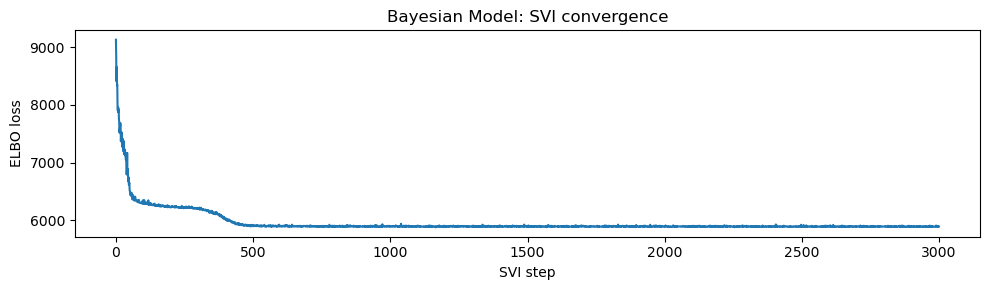


Posterior average class shares:
Class 1: 0.3431
Class 2: 0.6569

Bayesian Model predictive log-likelihood
Train LL: -5796.956
Test  LL: -1306.536

Bayesian model summary:
 K  prior_withconstraints  include_GA  n_params     train_ll      test_ll  final_elbo_loss
 2                  False        True        24 -5796.955894 -1306.536494      5889.764648
step    0 | ELBO loss = 9,092.55
step  500 | ELBO loss = 5,408.11
step 1000 | ELBO loss = 5,400.24
step 1500 | ELBO loss = 5,419.03
step 2000 | ELBO loss = 5,418.52
step 2500 | ELBO loss = 5,419.72
step 2999 | ELBO loss = 5,399.24

Bayesian Model — choice coefficients:
 class parameter   estimate
     1   beta_tt  -1.578674
     1   beta_co -12.010628
     1 ASC_alt_1   1.144296
     1 ASC_alt_2   2.345985
     2   beta_tt  -3.400407
     2   beta_co   0.155396
     2 ASC_alt_1   1.024281
     2 ASC_alt_2  -0.428719
     3   beta_tt   0.014601
     3   beta_co  -0.174578
     3 ASC_alt_1  -0.354612
     3 ASC_alt_2  -1.920923

Bayesian Mo

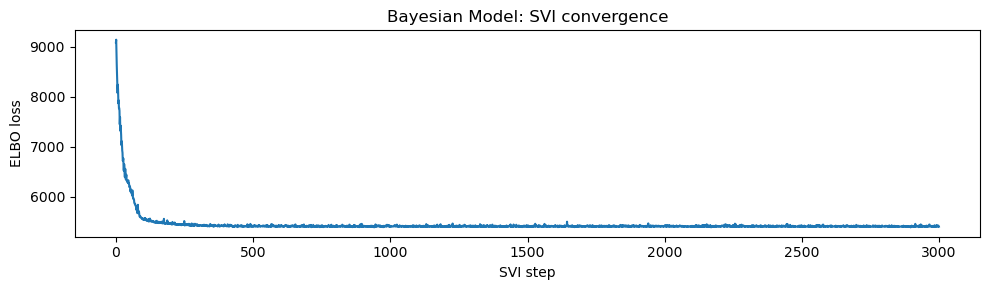


Posterior average class shares:
Class 1: 0.5220
Class 2: 0.3186
Class 3: 0.1594

Bayesian Model predictive log-likelihood
Train LL: -5265.876
Test  LL: -1230.104

Bayesian model summary:
 K  prior_withconstraints  include_GA  n_params     train_ll      test_ll  final_elbo_loss
 3                  False        True        44 -5265.876191 -1230.104128      5399.238281
step    0 | ELBO loss = 8,470.80
step  500 | ELBO loss = 6,024.78
step 1000 | ELBO loss = 5,946.07
step 1500 | ELBO loss = 5,945.04
step 2000 | ELBO loss = 5,938.06
step 2500 | ELBO loss = 5,942.54
step 2999 | ELBO loss = 5,950.47

Bayesian Model — choice coefficients:
 class parameter   estimate
     1   beta_tt  -1.402042
     1   beta_co -10.630919
     1 ASC_alt_1   1.563913
     1 ASC_alt_2   2.237348
     2   beta_tt  -0.311519
     2   beta_co  -0.291291
     2 ASC_alt_1   0.897855
     2 ASC_alt_2  -2.323499

Bayesian Model — membership coefficients:
     variable  gamma_class_1_vs_class_2
    intercept            

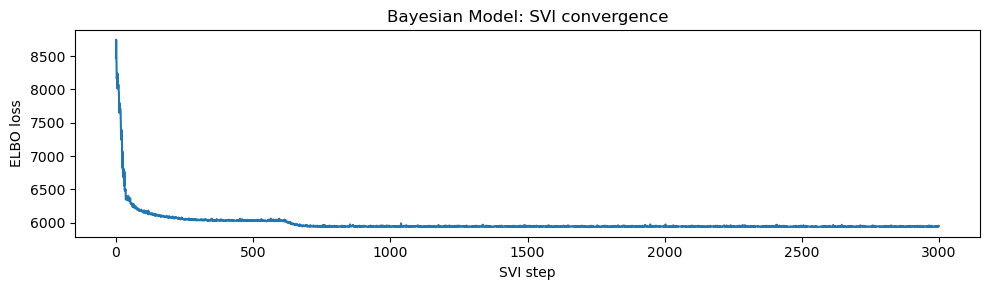


Posterior average class shares:
Class 1: 0.6437
Class 2: 0.3563

Bayesian Model predictive log-likelihood
Train LL: -5821.484
Test  LL: -1309.523

Bayesian model summary:
 K  prior_withconstraints  include_GA  n_params     train_ll      test_ll  final_elbo_loss
 2                   True        True        24 -5821.484263 -1309.523051      5950.473145
step    0 | ELBO loss = 8,543.44
step  500 | ELBO loss = 5,602.02
step 1000 | ELBO loss = 5,597.42
step 1500 | ELBO loss = 5,614.85
step 2000 | ELBO loss = 5,608.54
step 2500 | ELBO loss = 5,614.96
step 2999 | ELBO loss = 5,593.04

Bayesian Model — choice coefficients:
 class parameter   estimate
     1   beta_tt  -1.547752
     1   beta_co  -4.161602
     1 ASC_alt_1  -0.881601
     1 ASC_alt_2   2.045075
     2   beta_tt  -2.266472
     2   beta_co -10.741700
     2 ASC_alt_1   1.668183
     2 ASC_alt_2   1.916181
     3   beta_tt  -0.064287
     3   beta_co  -0.252628
     3 ASC_alt_1   0.826844
     3 ASC_alt_2  -2.529439

Bayesian Mo

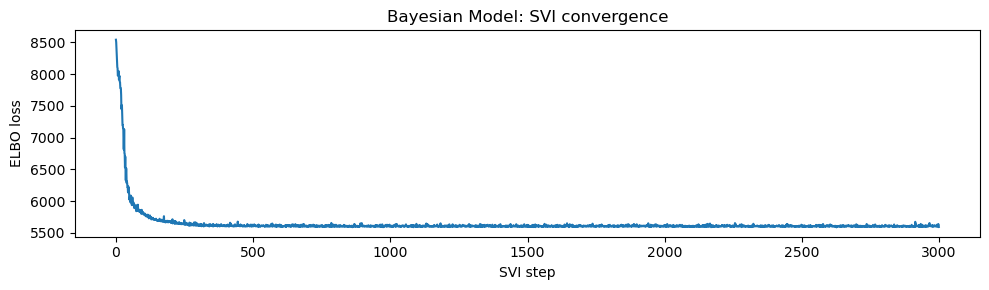


Posterior average class shares:
Class 1: 0.2444
Class 2: 0.5012
Class 3: 0.2544

Bayesian Model predictive log-likelihood
Train LL: -5423.588
Test  LL: -1218.906

Bayesian model summary:
 K  prior_withconstraints  include_GA  n_params     train_ll      test_ll  final_elbo_loss
 3                   True        True        44 -5423.587565 -1218.906197      5593.035645


In [14]:
# Bayesian LCCM with K=2 classes, no constraints, and GA included in membership model
Model6 = bayesian_lccm (K_b=2, df=df, long_df_train=long_df_train,long_df_test=long_df_test,prior_withconstraints=False)

# Bayesian LCCM with K=3 classes, no constraints, and GA included in membership model
Model7 = bayesian_lccm (K_b=3, df=df, long_df_train=long_df_train,long_df_test=long_df_test,prior_withconstraints=False)

# Bayesian LCCM with K=2 classes, with constraints, and GA included in membership model
Model8 = bayesian_lccm (K_b=2, df=df, long_df_train=long_df_train,long_df_test=long_df_test,prior_withconstraints=True)

# Bayesian LCCM with K=3 classes, with constraints, and GA included in membership model
Model9 = bayesian_lccm (K_b=3, df=df, long_df_train=long_df_train,long_df_test=long_df_test,prior_withconstraints=True)

#### Note that the coefficients of travel costs in Model 7 (no constraints) is positive

In [15]:
def summarize_bayesian_lccm_result(model_result, model_name):
    summary = model_result["summary"].copy()
    summary["model"] = model_name
    return summary


bayesian_summary_table = pd.DataFrame([
    summarize_bayesian_lccm_result(Model6, "Model 6"),
    summarize_bayesian_lccm_result(Model7, "Model 7"),
    summarize_bayesian_lccm_result(Model8, "Model 8"),
    summarize_bayesian_lccm_result(Model9, "Model 9"),
])

bayesian_summary_table = bayesian_summary_table[
    [
        "model",
        "K",
        "prior_withconstraints",
        "include_GA",
        "n_params",
        "train_ll",
        "test_ll",
        "final_elbo_loss",
    ]
]

print("\nBayesian LCCM summary comparison:")
print(bayesian_summary_table.to_string(index=False))


Bayesian LCCM summary comparison:
  model  K  prior_withconstraints  include_GA  n_params     train_ll      test_ll  final_elbo_loss
Model 6  2                  False        True        24 -5796.955894 -1306.536494      5889.764648
Model 7  3                  False        True        44 -5265.876191 -1230.104128      5399.238281
Model 8  2                   True        True        24 -5821.484263 -1309.523051      5950.473145
Model 9  3                   True        True        44 -5423.587565 -1218.906197      5593.035645
